K-Means is an unsupervised machine learning algorithm used to group similar data points into K clusters.

How it works:

Choose K (number of clusters).
Randomly initialize K centroids.
Assign each data point to the nearest centroid.
Recalculate the centroid of each cluster.
Repeat steps 3–4 until the centroids stop changing.

Example:
If customer data is clustered with K = 3, the algorithm may create groups like:

High spenders
Medium spenders
Low spenders

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import pairplot
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# For dataset
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

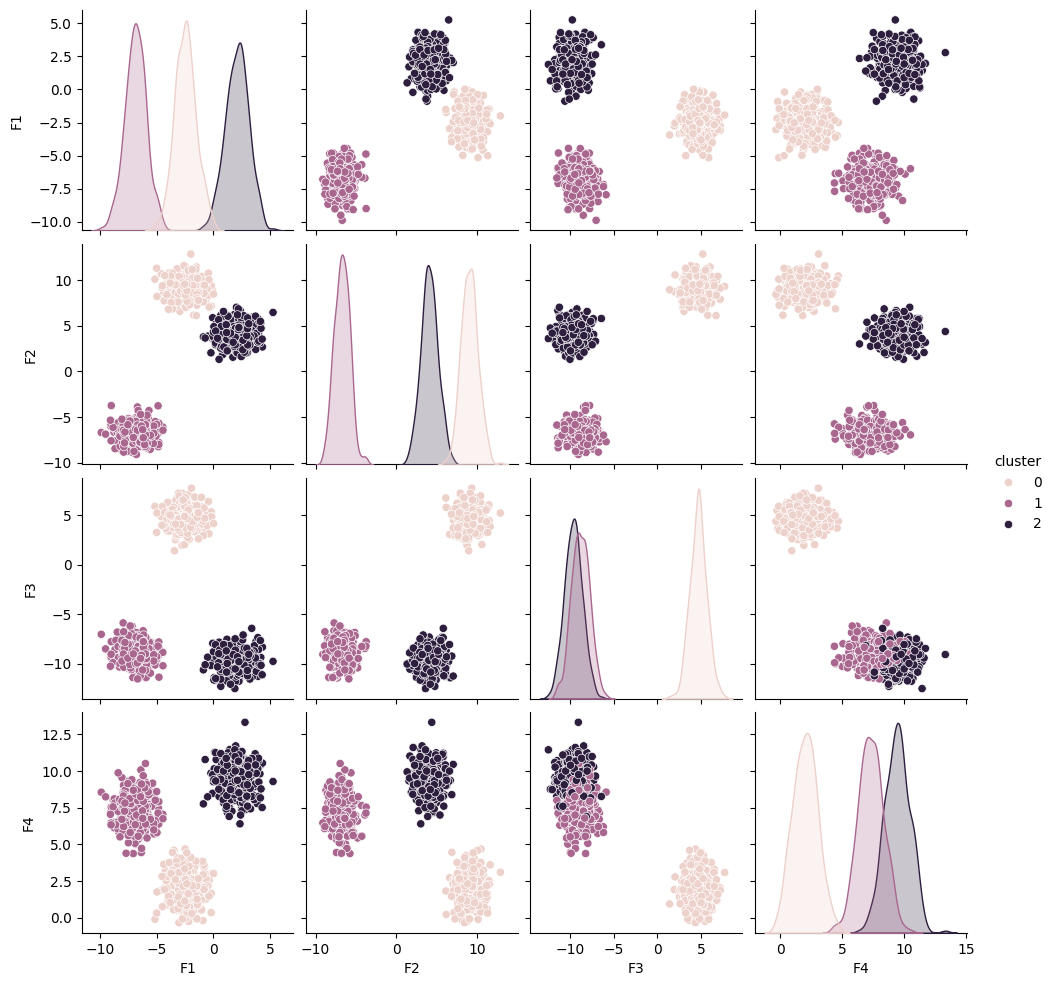

In [20]:
x,y=make_blobs(n_samples=1000,n_features=4,centers=3,random_state=42)
# to load dataset we used y but in unsupervised we will not use y.

df=pd.DataFrame(x,columns=['F1','F2','F3','F4'])
df['cluster']=y
sns.pairplot(df,hue='cluster')
plt.show()

pridicted cluster lebel for each training samle [1 1 0 2 1 2 0 0 1 1 0 2 1 1 0 0 0 1 2 0 0 0 2 0 0 0 0 2 1 2 2 2 2 1 1 1 2
 1 0 2 0 0 0 1 2 2 2 0 1 2 1 2 2 1 0 0 0 0 0 2 2 0 2 2 0 1 0 2 2 0 1 1 2 1
 2 1 0 1 1 2 0 0 2 0 1 1 0 2 1 2 0 1 1 0 1 1 1 0 0 1 1 0 2 2 0 0 1 2 1 2 0
 1 2 2 1 0 0 2 0 2 2 1 2 2 2 2 2 0 1 2 1 2 0 0 2 0 0 0 2 2 0 0 1 2 0 2 2 0
 1 0 2 0 2 0 2 0 1 2 0 1 1 2 0 1 2 2 1 2 1 2 0 1 0 1 0 2 2 1 0 1 1 1 2 1 1
 1 2 2 2 2 0 1 0 1 1 2 0 1 1 2 2 2 0 2 2 1 1 2 0 0 1 0 0 2 0 2 0 1 0 1 0 1
 0 1 1 1 0 1 2 0 0 1 2 0 2 0 2 1 0 0 0 1 0 1 1 0 1 0 2 0 2 0 0 1 0 0 1 2 2
 0 1 1 0 1 1 2 1 0 1 2 0 2 0 0 0 0 1 0 2 2 1 1 2 1 0 1 0 1 0 2 1 2 2 2 2 1
 0 0 0 1 0 2 1 2 0 2 1 0 0 2 1 0 2 2 0 2 1 2 1 2 2 2 1 1 2 1 2 2 2 0 1 1 2
 0 1 1 0 0 0 0 1 0 2 0 0 0 1 2 1 1 1 2 0 2 1 0 0 2 1 1 2 1 0 0 2 0 1 0 0 1
 2 0 1 1 1 2 0 2 1 2 2 1 2 0 0 2 1 0 0 0 0 1 2 0 0 1 1 2 1 1 0 1 2 1 1 1 2
 1 1 0 0 0 0 0 2 0 2 2 1 1 2 2 0 2 2 2 0 0 2 1 0 2 0 2 2 1 2 2 2 0 1 2 0 0
 1 2 0 0 0 0 2 1 1 0 1 1 2 1 2 1 1 0 1 0 0 1 2 2 1 2

[84446.08469874336,
 28551.16868932549,
 3013.847118342812,
 2841.060719049472,
 2649.0672010998596,
 2526.7613840150757,
 2307.627192298152,
 2351.182090803465,
 2125.5152885001967]

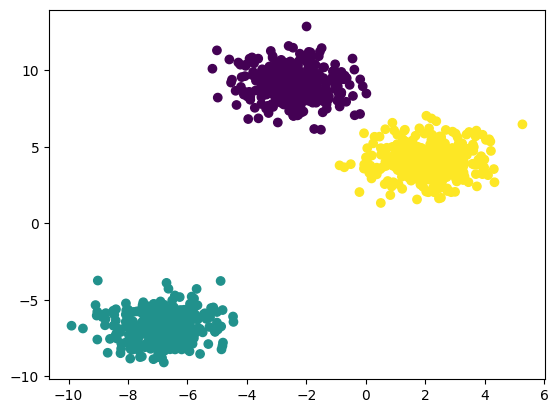

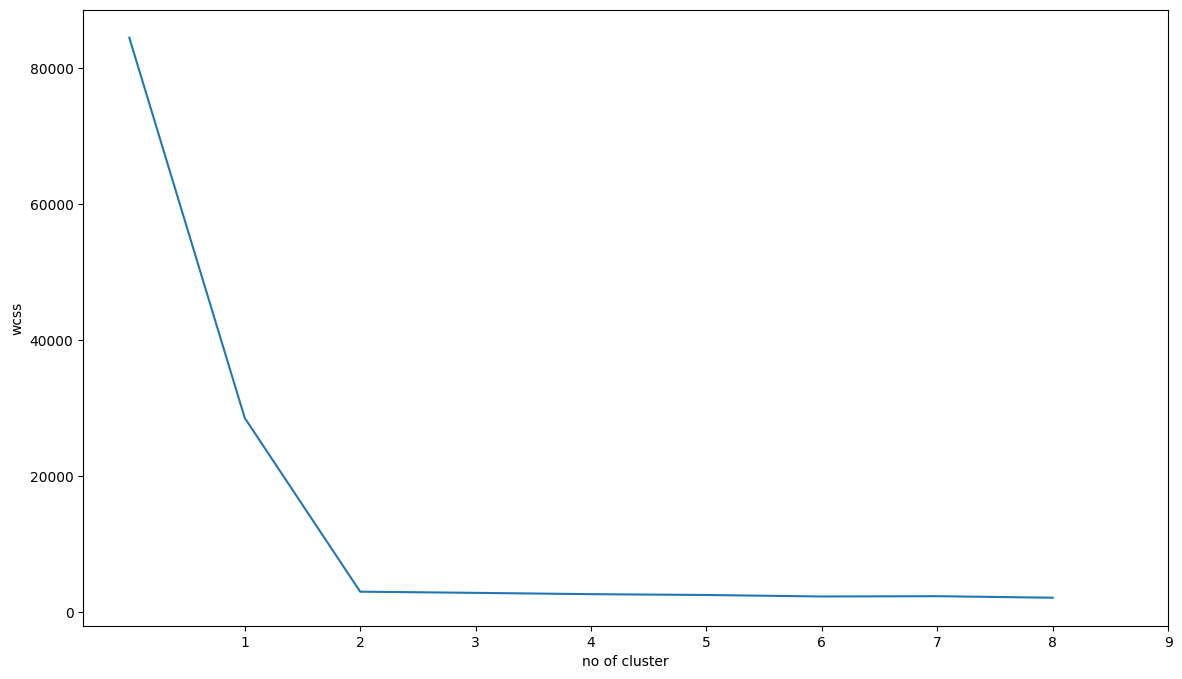

In [39]:
plt.scatter(x[:,0],x[:,1],c=y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
from sklearn.cluster import KMeans
kmn=KMeans(n_clusters=3)
kmn.fit(x_train)
y_lebel=kmn.predict(x_train)
print(f"pridicted cluster lebel for each training samle {y_lebel}")

# to see how much perfect the model is :
from sklearn.metrics import silhouette_score
score=silhouette_score(x_train,kmn.labels_)
print(score)

#Inertia = Within Cluster Sum of Squares (WCSS). Ye batata hai ki har data point apne assigned centroid se kitni door hai.
print(f" this is with k=3 {kmn.inertia_}")
wcss=[]
for k in range(1,10):
    kmns=KMeans(n_clusters=k)
    kmns.fit(x_train)
    wcss.append(kmns.inertia_)
display(wcss)
plt.figure(figsize=(14,8))
plt.plot(wcss)
plt.xticks(range(1,10))
plt.xlabel("no of cluster")
plt.ylabel("wcss")
plt.show() # where sharp turn takse place that would be the best no of cluster ( k )

In [38]:
# for value of k 
from kneed import KneeLocator
k1=KneeLocator(range(1,10),wcss,curve='convex',direction='decreasing')
print(k1.elbow)

# checking silhouette_score
sil_coef=[]
for i in range(2,10):
    kmns=KMeans(n_clusters=i)
    kmns.fit(x_train)
    score=silhouette_score(x_train,kmns.labels_)
    sil_coef.append(score)
    
display(sil_coef)

3


[0.6607174704729812,
 0.8253570216102465,
 0.6235716384973641,
 0.5981762222533095,
 0.3716438618961204,
 0.17485366024608326,
 0.17458417364207796,
 0.17196183405758306]